Code to generate Header score cards:

*  Total GMV in INR = sum of amount_inr in ledger
*  overall success rate = count of transactions with status captured / total transactions in ledger
*  reconciliation match_rate = (count of transactions present in BOTH ledger.csv and gateway_export.csv with an identical amount_inr AND an identical status) / (total transaction count in ledger.csv)
*   chargeback_ratio (headline) = (count of transactions with status == "chargeback") / (count of all transactions), platform-wide, expressed as a percentage — count-based, not amount-based.






In [1]:
import matplotlib.pyplot as plt

def create_scorecard(ax, label, value):
  #fig, ax = plt.subplots(figsize=(2.5, 1.5))
  ax.axis('off')

  ax.text(0.5, 0.7, label, fontsize=14, ha='center')
  ax.text(0.5, 0.4, value, fontsize=14, ha='center', color='blue')
  rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", linewidth=2)
  ax.add_patch(rect)

In [2]:
def create_header_plot(data):
  fig, (axs1, axs2, axs3, axs4) = plt.subplots(1, 4, figsize=(16, 2))
  create_scorecard(axs1, data[0]["label"], data[0]["value"])
  create_scorecard(axs2, data[1]["label"], data[1]["value"])
  create_scorecard(axs3, data[2]["label"], data[2]["value"])
  create_scorecard(axs4, data[3]["label"], data[3]["value"])
  plt.show()

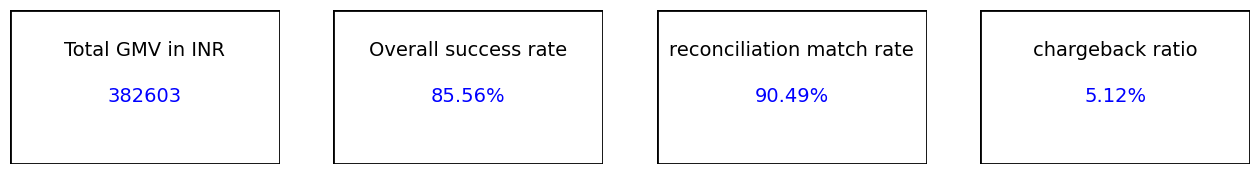

In [3]:
import pandas as pd

#TODO:: Add code to create df for visualizing the below 4 score cards
ledger_df = pd.read_csv("ledger.csv")
gateway_df = pd.read_csv("gateway_export.csv")
merchant_df = pd.read_csv("merchants.csv")

total_gmv = ledger_df['amount_inr'].sum()
overall_success = len(ledger_df[ledger_df['status'] == 'captured']) / len(ledger_df) * 100
chargeback_ratio = len(ledger_df[ledger_df['status'] == 'chargeback']) / len(ledger_df) * 100

# Now calculating reconciliation match_rate
ledger_ids = set(ledger_df['transaction_id'])
gateway_ids = set(gateway_df['transaction_id'])
common_ids = ledger_ids & gateway_ids
common_ledger_df = ledger_df[ledger_df['transaction_id'].isin(common_ids)]
common_gateway_df = gateway_df[gateway_df['transaction_id'].isin(common_ids)]
comparison_df = pd.merge(common_ledger_df, common_gateway_df, on='transaction_id', suffixes=("_gateway", "_ledger"))
common_df = comparison_df[ (comparison_df['amount_inr_ledger'] == comparison_df['amount_inr_gateway']) &
                          (comparison_df['status_ledger'] ==comparison_df['status_gateway']) ].copy()
reconciliation_match_rate = len(common_df) / len(ledger_df) * 100

data = [
    {"label":"Total GMV in INR", "value": total_gmv},
    {"label":"Overall success rate", "value": f"{overall_success:.2f}%" },
    {"label":"reconciliation match rate", "value": f"{reconciliation_match_rate:.2f}%" },
    {"label":"chargeback ratio", "value": f"{chargeback_ratio:.2f}%"}]

create_header_plot(data)

Here is the code to generate Trends layer - Time series chart for GMV and chargeback count for each day

In [4]:
ledger_df['transaction_date'] = pd.to_datetime(ledger_df['transaction_time']).dt.date
ledger_chart_gmv_df = ledger_df.groupby('transaction_date')['amount_inr'].sum()
ledger_chart_chargeback_df = ledger_df[ledger_df['status'] == 'chargeback'].groupby('transaction_date')['amount_inr'].count()
ledger_chart_df = pd.merge(ledger_chart_gmv_df, ledger_chart_chargeback_df, on = 'transaction_date',
                           how="outer", suffixes=("_gmv", "_chargeback_count")).fillna(0)
ledger_chart_df['amount_inr_chargeback_count'] = ledger_chart_df['amount_inr_chargeback_count'].astype(int)
#ledger_chart_df.head()

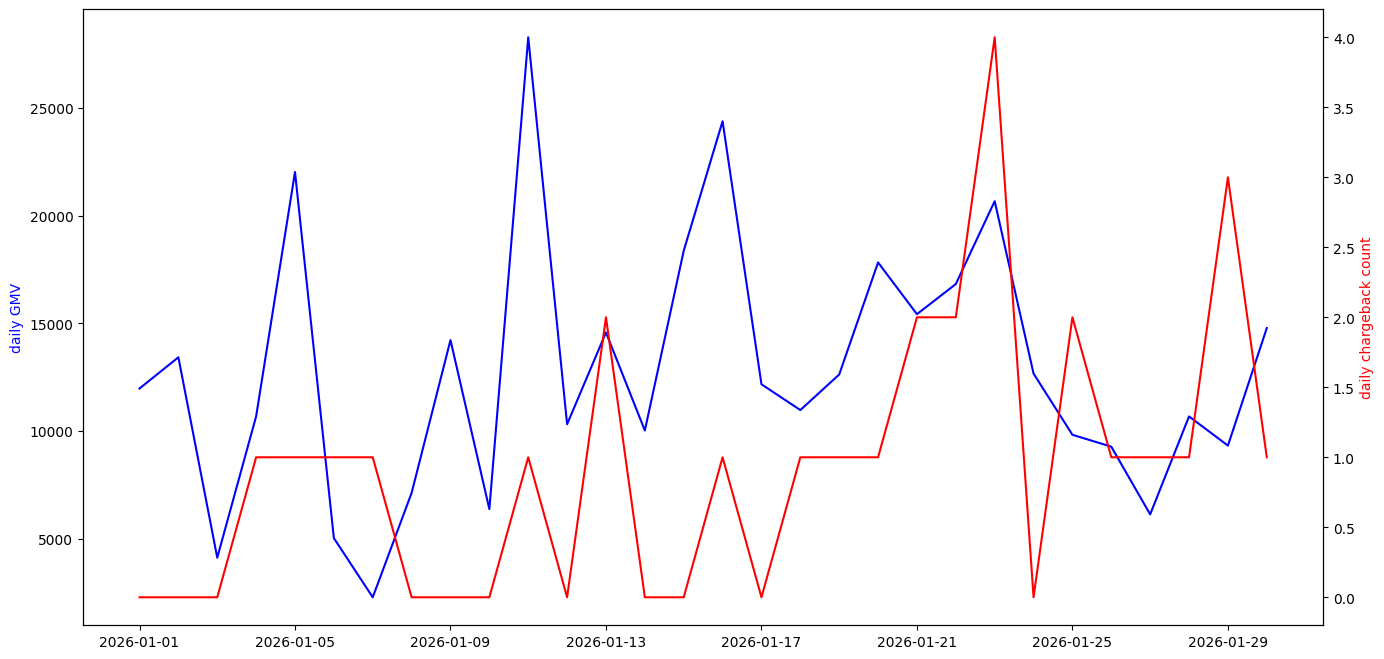

In [5]:
fig, ax1 = plt.subplots(figsize=(16, 8))
ax1.plot(ledger_chart_df.index, ledger_chart_df['amount_inr_gmv'], color='blue')
ax1.set_ylabel("daily GMV").set_color('blue')
ax2 = ax1.twinx()
ax2.plot(ledger_chart_df.index, ledger_chart_df['amount_inr_chargeback_count'], color='red')
ax2.set_ylabel("daily chargeback count").set_color('red')

Code to create bar chart of Total GMV by payment_method and Total GMV by category (joined from merchants)

<Axes: xlabel='category'>

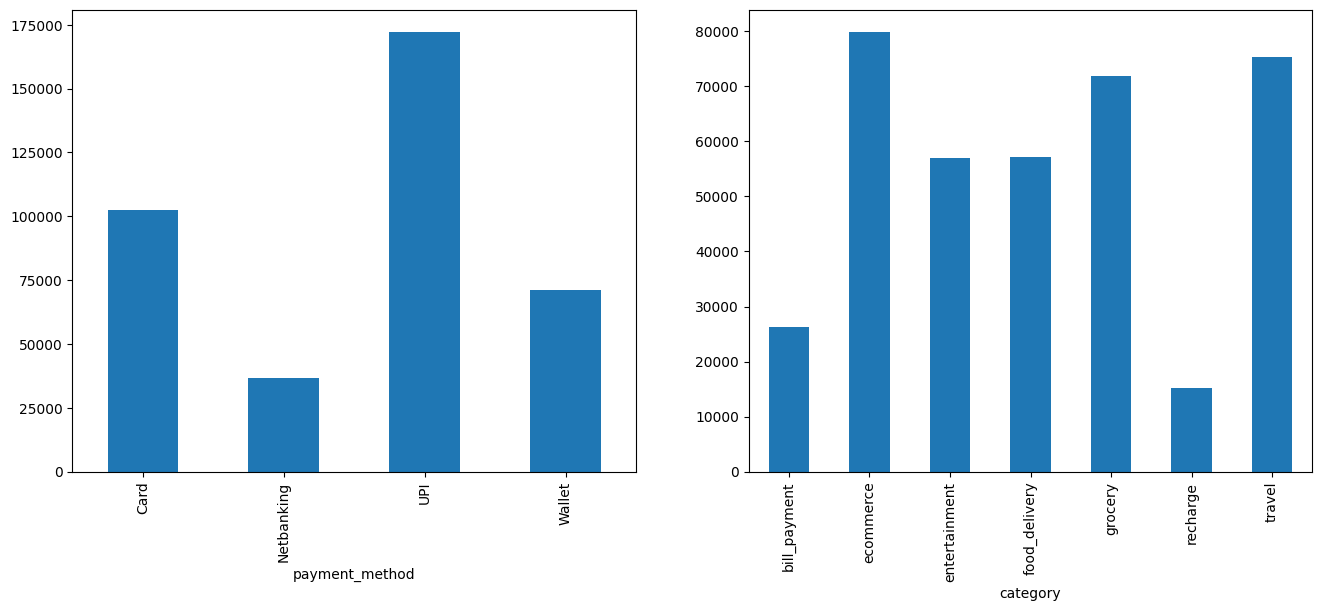

In [6]:
payment_method_agg_df = ledger_df.groupby('payment_method')['amount_inr'].sum()
ledger_merchant_category_df = pd.merge(ledger_df, merchant_df, on='merchant_id')
merchant_category_agg_df = ledger_merchant_category_df.groupby('category')['amount_inr'].sum()

fig, (axs1, axs2) = plt.subplots(1, 2, figsize=(16, 6))
payment_method_agg_df.plot(ax=axs1, x='payment_method', y='amount_inr',kind='bar')
merchant_category_agg_df.plot(ax=axs2, x='category', y='amount_inr', kind='bar')

Code to create a table of top 10 merchants by transaction count, with conditional highlighting (e.g., a flag column) for any merchant whose chargeback_ratio exceeds 1% : chargeback_ratio (per-merchant) = (count of that merchant's transactions with status == "chargeback") / (count of all of that merchant's transactions).

In [7]:
top_merchants_df = ledger_df.groupby('merchant_id')['transaction_id'].count().to_frame()
top_merchants_df = top_merchants_df.rename(columns={'transaction_id':'transaction_count'})
#print(top_merchants_df.head())
merchants_chargeback_df = ledger_df[ledger_df['status'] == 'chargeback'].groupby('merchant_id')['transaction_id'].count().to_frame().rename(columns={'transaction_id':'chargeback_count'})
#print(merchants_chargeback_df.head())
top_merchants_flag_df  = pd.merge(top_merchants_df, merchants_chargeback_df, on='merchant_id', how='left')
top_merchants_flag_df['chargeback_count'] = top_merchants_flag_df['chargeback_count'].fillna(0)
top_merchants_flag_df['flag'] = top_merchants_flag_df['chargeback_count'] / top_merchants_flag_df['transaction_count'] * 100 > 1
top_merchants_flag_df = top_merchants_flag_df.sort_values(by='transaction_count', ascending=False)
#print(top_merchants_flag_df.head())

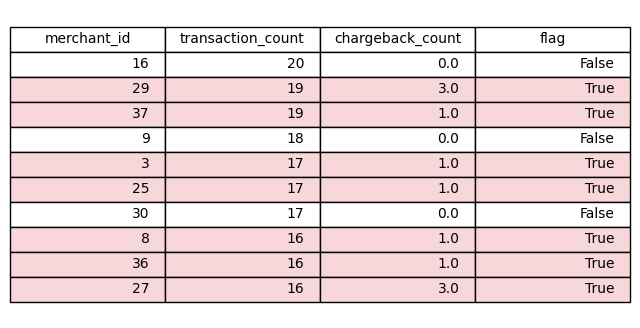

In [8]:
import numpy as np

plot_df = top_merchants_flag_df.head(10).reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
cell_colors = np.full(plot_df.shape, '#ffffff', dtype=object)
for row in range(len(plot_df)):
    if plot_df.iloc[row]['flag']:
        cell_colors[row, :] = '#f8d7da'

table = ax.table(
    cellText=plot_df.values,
    colLabels=plot_df.columns,
    cellColours=cell_colors,
    loc='center'
)
table.scale(1, 1.5)
plt.show()